In [1]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import Subset,DataLoader
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

In [3]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])
train_dataset = datasets.MNIST(root="data",train=True,download=True,transform=transform)
test_dataset = datasets.MNIST(root="data",train=False,download=True,transform=transform)

In [4]:
len(train_dataset),len(test_dataset)

(60000, 10000)

In [5]:
torch.arange(5000)

tensor([   0,    1,    2,  ..., 4997, 4998, 4999])

In [6]:
train_subset = Subset(train_dataset,torch.arange(5000))
test_subset = Subset(test_dataset,torch.arange(1000))

In [7]:
train_loader = DataLoader(train_subset,batch_size=60,shuffle=True)
test_loader = DataLoader(test_subset,batch_size=60,shuffle=True)

In [8]:
images,labels = next(iter(train_loader))
images.shape

torch.Size([60, 1, 28, 28])

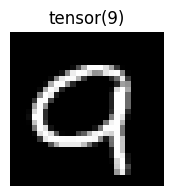

In [9]:
plt.figure(figsize=(2,2))
plt.imshow(images[0].squeeze(),cmap='gray')
plt.title(labels[0])
plt.axis("off")
plt.show()


In [10]:
len(train_loader)

84

### Creating NN

In [11]:
class MnistClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)

In [12]:
model = MnistClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [13]:
def model_train(model,criterion,optimizer,train_loader,test_loader,epochs=10):
    val_accuracies = []
    for epoch in range(epochs):
        model.train()
        for batch,(images,labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            if (batch)%100 == 0:
                print(f"Epoch: {epoch+1}/{epochs}, Batch:{batch+1}/{len(train_loader)}, Loss: {loss.item():.3f}")
    
        model.eval()
        all_true,all_pred = [],[]
        with torch.no_grad():
            for images,labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                _,pred = torch.max(outputs,1)
                all_true.extend(labels.cpu().numpy())
                all_pred.extend(pred.cpu().numpy())
            val_acc = accuracy_score(all_true,all_pred)
            val_accuracies.append(val_acc)
    return val_accuracies

In [14]:
val_accuracies = model_train(model,criterion,optimizer,train_loader,test_loader,epochs=10)

Epoch: 1/10, Batch:1/84, Loss: 2.296
Epoch: 2/10, Batch:1/84, Loss: 0.395
Epoch: 3/10, Batch:1/84, Loss: 0.290
Epoch: 4/10, Batch:1/84, Loss: 0.199
Epoch: 5/10, Batch:1/84, Loss: 0.551
Epoch: 6/10, Batch:1/84, Loss: 0.179
Epoch: 7/10, Batch:1/84, Loss: 0.154
Epoch: 8/10, Batch:1/84, Loss: 0.165
Epoch: 9/10, Batch:1/84, Loss: 0.157
Epoch: 10/10, Batch:1/84, Loss: 0.074


In [15]:
val_accuracies

[0.831, 0.863, 0.864, 0.86, 0.889, 0.887, 0.886, 0.892, 0.893, 0.885]

### NN with Batch Norm

In [21]:
class MnistClassifier_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)

In [22]:
model_with_bn = MnistClassifier_BN().to(device)
criterion_with_bn = nn.CrossEntropyLoss()
optimizer_with_bn = optim.Adam(model_with_bn.parameters(),lr=0.001)
val_accuracies_bn = model_train(model_with_bn,criterion_with_bn,optimizer_with_bn,train_loader,test_loader,epochs=10)

Epoch: 1/10, Batch:1/84, Loss: 2.399
Epoch: 2/10, Batch:1/84, Loss: 0.251
Epoch: 3/10, Batch:1/84, Loss: 0.178
Epoch: 4/10, Batch:1/84, Loss: 0.185
Epoch: 5/10, Batch:1/84, Loss: 0.098
Epoch: 6/10, Batch:1/84, Loss: 0.076
Epoch: 7/10, Batch:1/84, Loss: 0.017
Epoch: 8/10, Batch:1/84, Loss: 0.024
Epoch: 9/10, Batch:1/84, Loss: 0.019
Epoch: 10/10, Batch:1/84, Loss: 0.073


In [23]:
val_accuracies_bn

[0.893, 0.914, 0.9, 0.929, 0.923, 0.93, 0.939, 0.934, 0.933, 0.942]

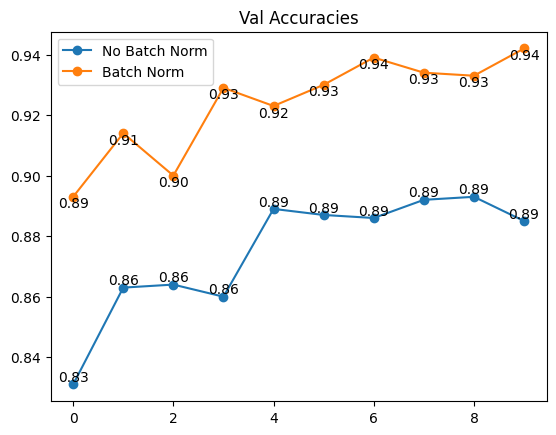

In [29]:
plt.plot(val_accuracies, label="No Batch Norm", marker='o')
plt.plot(val_accuracies_bn, label="Batch Norm", marker='o')

# Values for first line
for i, v in enumerate(val_accuracies):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

# Values for second line
for i, v in enumerate(val_accuracies_bn):
    plt.text(i, v, f"{v:.2f}", ha='center', va='top')

plt.title("Val Accuracies")
plt.legend()
plt.show()